In [1]:
!pip install onnx
!pip install onnxscript

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime
from time import time

# Load Teacher Model

In [3]:
# Load a pre-trained CIFAR-10 ResNet-18 from a reliable community hub
teacher = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
teacher.eval() # Always set teacher to eval mode

Using cache found in /home/kastel/ja1993/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

# Paulsen Model

In [4]:
def make_cnn_5layer_batchnorm(in_ch, in_dim, width=2, linear_size=256, act_fun=nn.GELU, act_kwargs={}):
    model = nn.Sequential(
        nn.Conv2d(in_ch, width, 3, stride=1, padding=1),
        act_fun(**act_kwargs),
        nn.BatchNorm2d(width),
        nn.Conv2d(width, width, 3, stride=1, padding=1),
        act_fun(**act_kwargs),
        nn.BatchNorm2d(width),
        nn.Conv2d(width, 2 * width, 3, stride=2, padding=1),
        act_fun(),
        nn.BatchNorm2d(2 * width),
        nn.Flatten(),
        nn.Linear((in_dim//2) * (in_dim//2) * 2 * width, linear_size),
        act_fun(**act_kwargs),
        nn.Linear(linear_size,10)
    )
    return model

# Ultry-Tiny Model

In [5]:
def make_cnn_tiny(in_ch, in_dim, width=16, linear_size=256, act_fun=nn.GELU, act_kwargs={}):
    model = nn.Sequential(
        nn.Conv2d(in_ch, width, 3, stride=2, padding=1),
        act_fun(**act_kwargs),
        nn.BatchNorm2d(width),
        nn.Conv2d(width, 2*width, 3, stride=2, padding=1),
        act_fun(**act_kwargs),
        nn.BatchNorm2d(2*width),
        nn.Conv2d(2*width, 4*width, 3, stride=2, padding=1),
        act_fun(),
        nn.BatchNorm2d(4 * width),
        nn.Flatten(),
        nn.Linear((in_dim//8) * (in_dim//8) * 4 * width, linear_size),
        act_fun(**act_kwargs),
        nn.Linear(linear_size,10)
    )
    return model

# Data Loader

In [6]:
def get_loaders(batch_size=64, num_workers=2, auto_augment=False):
    # Statistiche CIFAR-10 standard
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    if auto_augment:
        train_tf = transforms.Compose([
            transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.RandomCrop(32, padding=4),       # augmentation fondamentale
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_ds = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

# Knowledge Distillation Training

In [7]:
def train_one_epoch_kd(student, teacher, dataloader, optimizer, device, alpha=0.5, T=4.0):
    student.train()
    teacher.eval()
    
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Student forward pass
        s_logits = student(inputs)
        
        # Teacher forward pass (no gradients needed)
        with torch.no_grad():
            t_logits = teacher(inputs)

        # 1. Hard Loss: Standard CrossEntropy
        loss_hard = F.cross_entropy(s_logits, labels)
        
        # 2. Soft Loss: KL Divergence between softened distributions
        # We use log_softmax for student and softmax for teacher
        loss_soft = F.kl_div(
            F.log_softmax(s_logits / T, dim=1),
            F.softmax(t_logits / T, dim=1),
            reduction='batchmean'
        ) * (T * T) # Scale by T^2 to keep gradients consistent

        # Combine losses
        loss = (1 - alpha) * loss_hard + (alpha * loss_soft)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (s_logits.argmax(1) == labels).sum().item()
        total      += inputs.size(0)
        
    return total_loss / len(dataloader), correct / total

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

# FitNets Hint Training

In [10]:
class FeatureHook:
    def __init__(self, module):
        self.hook = module.register_forward_hook(self.hook_fn)
        self.data = None

    def hook_fn(self, module, input, output):
        self.data = output

    def close(self):
        self.hook.remove()

In [11]:
def train_one_epoch_fitnet(epoch, student, teacher, regressor, student_hook, teacher_hook, loader, optimizer, device, alpha=0.5, beta=100.0, T=2.0, warmup=20, beta2=1000):
    student.train()
    teacher.eval()

    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward passes
        s_logits = student(inputs)
        with torch.no_grad():
            t_logits = teacher(inputs)

        # Extract hooked features
        s_feat = student_hook.data # Shape: [batch, width, 32, 32] -> Actually 32x32 because stride=2 hasn't happened yet
        t_feat = teacher_hook.data # Shape: [batch, 32, 16, 16]

        # NOTE: If spatial sizes don't match, we use interpolate or AdaptiveAvgPool
        # s_feat is 32x32, t_feat is 16x16. Let's downsample s_feat.
        s_feat_resized = F.interpolate(s_feat, size=(16, 16), mode='bilinear', align_corners=False)

        # 1. Hint Loss (MSE between projected student and teacher)
        projected_s = regressor(s_feat_resized)
        loss_hint = F.mse_loss(projected_s, t_feat)

        # 2. Distillation Loss (KL)
        loss_kd = F.kl_div(
            F.log_softmax(s_logits / T, dim=1),
            F.softmax(t_logits / T, dim=1),
            reduction='batchmean'
        ) * (T * T)

        # 3. Hard Label Loss
        loss_ce = F.cross_entropy(s_logits, labels)

        if epoch <= warmup:
            # hint-only training for the first few epochs
            loss = loss_hint * beta2
        else:
            # beta is a hyperparameter to scale the hint loss
            loss = (1 - alpha) * loss_ce + (alpha * loss_kd) + (beta * loss_hint)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (s_logits.argmax(1) == labels).sum().item()
        total      += inputs.size(0)

    return total_loss / total, correct / total

# Full Training Loop

In [12]:
def train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, knowledge_distillation=True, fitnet=False, width=2, alpha=0.5, T=2.0, warmup=10, beta=100.0, auto_augment=False):
    DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
    
    print(f"Device: {DEVICE}")
    
    train_loader, test_loader = get_loaders(batch_size=batch_size, auto_augment=auto_augment)
    
    model     = make_cnn_5layer_batchnorm(3, 32, width=width, linear_size=256, act_fun=nn.GELU).to(DEVICE)
    teacher   = teacher.to(DEVICE)
    regressor = None
    student_hook = None
    teacher_hook = None
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)  # Gemini said standard Adam doesn't work well with CosineAnnealing

    if fitnet:
        # We hook the 6th element (the second BatchNorm2d)
        student_hook = FeatureHook(model[5]) 
        
        # resnet20.layer2 is a good middle-ground hint
        teacher_hook = FeatureHook(teacher.layer2)
        
        # 3. The Regressor (Crucial!)
        # Student width=width, Teacher layer2 width=32. Spatial size for both is 16x16.
        regressor = nn.Conv2d(width, 32, kernel_size=1).to(DEVICE)
        
        optimizer = optim.AdamW(list(model.parameters()) + list(regressor.parameters()), lr=1e-3)

    
    # Cosine annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # number of parameters
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {n_params:,}\n")
    
    teacher.eval()

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    best_file = f"best_model_{timestamp}.pth"

    t_start = time()
    best_acc = 0.0
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    for epoch in range(1, epochs + 1):
        if fitnet:
            train_loss, train_acc = train_one_epoch_fitnet(epoch, model, teacher, regressor, student_hook, teacher_hook, 
                                                           train_loader, optimizer, DEVICE, alpha=alpha, beta=beta, T=T, warmup=warmup)
        elif (epoch < warmup and knowledge_distillation) or (not knowledge_distillation):
            # warmup student with normal training
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        else:
            # now use student-teacher training (knowledge distillation)
            train_loss, train_acc = train_one_epoch_kd(model, teacher, train_loader, optimizer, DEVICE, alpha=alpha, T=T)
            
        test_loss,  test_acc  = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()
    
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), best_file)

        t_cur = time()
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss {train_loss:.3f} acc {train_acc*100:.1f}% | "
              f"test loss {test_loss:.3f} acc {test_acc*100:.1f}% | "
              f"best {best_acc*100:.1f}%  - ({t_cur - t_start} sec)")
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    
    print(f"\nBest test accuracy: {best_acc*100:.2f}%")

    return model, best_file, train_losses, test_losses, train_accs, test_accs

## Variable Model

In [13]:
def train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, knowledge_distillation=True, fitnet=False, width=2, alpha=0.5, T=2.0, 
                              warmup=10, beta=100.0, auto_augment=False):
    DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
    
    print(f"Device: {DEVICE}")
    
    train_loader, test_loader = get_loaders(batch_size=batch_size, auto_augment=auto_augment)

    model     = model.to(DEVICE)
    teacher   = teacher.to(DEVICE)
    regressor = None
    student_hook = None
    teacher_hook = None
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)  # Gemini said standard Adam doesn't work well with CosineAnnealing

    if fitnet:
        # We hook the 6th element (the second BatchNorm2d)
        student_hook = FeatureHook(model[5]) 
        
        # resnet20.layer2 is a good middle-ground hint
        teacher_hook = FeatureHook(teacher.layer2)
        
        # 3. The Regressor (Crucial!)
        # Student width=width, Teacher layer2 width=32. Spatial size for both is 16x16.
        regressor = nn.Conv2d(width, 32, kernel_size=1).to(DEVICE)
        
        optimizer = optim.AdamW(list(model.parameters()) + list(regressor.parameters()), lr=lr)

    
    # Cosine annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # number of parameters
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {n_params:,}\n")
    
    teacher.eval()

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    best_file = f"best_model_{timestamp}.pth"

    t_start = time()
    best_acc = 0.0
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    for epoch in range(1, epochs + 1):
        if fitnet:
            train_loss, train_acc = train_one_epoch_fitnet(epoch, model, teacher, regressor, student_hook, teacher_hook, 
                                                           train_loader, optimizer, DEVICE, alpha=alpha, beta=beta, T=T, warmup=warmup)
        elif (epoch < warmup and knowledge_distillation) or (not knowledge_distillation):
            # warmup student with normal training
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        else:
            # now use student-teacher training (knowledge distillation)
            train_loss, train_acc = train_one_epoch_kd(model, teacher, train_loader, optimizer, DEVICE, alpha=alpha, T=T)
            
        test_loss,  test_acc  = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()
    
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), best_file)

        t_cur = time()
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss {train_loss:.3f} acc {train_acc*100:.1f}% | "
              f"test loss {test_loss:.3f} acc {test_acc*100:.1f}% | "
              f"best {best_acc*100:.1f}%  - ({t_cur - t_start} sec)")
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    
    print(f"\nBest test accuracy: {best_acc*100:.2f}%")

    return model, best_file, train_losses, test_losses, train_accs, test_accs

# Start Training

In [12]:
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model     = make_cnn_5layer_batchnorm(3, 32, width=2, linear_size=256, act_fun=nn.GELU).to(DEVICE)
teacher   = teacher.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)  # Gemini said standard Adam doesn't work well with CosineAnnealing

# Cosine annealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# number of parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}\n")

teacher.eval()

best_acc = 0.0
train_losses = []
test_losses = []
for epoch in range(1, EPOCHS + 1):
    if epoch < 10:
        # warmup student with normal training
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    else:
        # now use student-teacher training (knowledge distillation)
        train_loss, train_acc = train_one_epoch_kd(model, teacher, train_loader, optimizer, DEVICE, alpha=0.5, T=4.0)
        
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model_student.pth")

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train loss {train_loss:.3f} acc {train_acc*100:.1f}% | "
          f"test loss {test_loss:.3f} acc {test_acc*100:.1f}% | "
          f"best {best_acc*100:.1f}%")
    train_losses.append(train_loss)
    test_losses.append(test_loss)

print(f"\nBest test accuracy: {best_acc*100:.2f}%")

Device: cuda


100%|██████████| 170M/170M [00:06<00:00, 25.3MB/s] 
/usr/lib64/python3.11/tarfile.py:2302: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  warnings.warn(


Parameters: 265,156

Epoch   1/100 | train loss 1.724 acc 37.7% | test loss 1.454 acc 48.1% | best 48.1%
Epoch   2/100 | train loss 1.478 acc 46.9% | test loss 1.347 acc 52.5% | best 52.5%
Epoch   3/100 | train loss 1.394 acc 50.1% | test loss 1.292 acc 54.9% | best 54.9%
Epoch   4/100 | train loss 1.345 acc 52.3% | test loss 1.269 acc 54.5% | best 54.9%
Epoch   5/100 | train loss 1.308 acc 53.6% | test loss 1.245 acc 55.7% | best 55.7%
Epoch   6/100 | train loss 1.279 acc 54.7% | test loss 1.200 acc 58.2% | best 58.2%
Epoch   7/100 | train loss 1.258 acc 55.6% | test loss 1.189 acc 58.3% | best 58.3%
Epoch   8/100 | train loss 1.232 acc 56.2% | test loss 1.160 acc 59.3% | best 59.3%
Epoch   9/100 | train loss 1.217 acc 57.1% | test loss 1.160 acc 59.4% | best 59.4%
Epoch  10/100 | train loss 5.327 acc 55.3% | test loss 1.566 acc 59.2% | best 59.4%
Epoch  11/100 | train loss 5.106 acc 57.2% | test loss 1.510 acc 59.9% | best 59.9%
Epoch  12/100 | train loss 4.978 acc 58.1% | test loss 

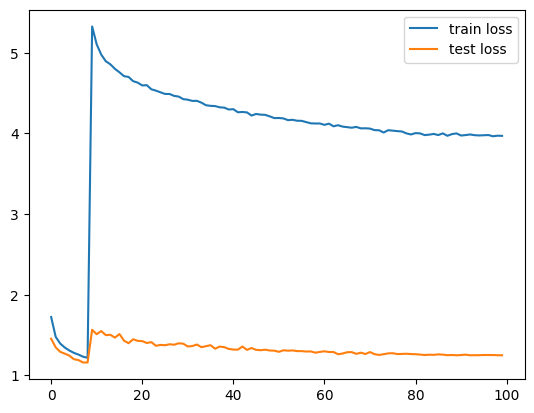

In [13]:
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.legend()

In [14]:
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model     = make_cnn_5layer_batchnorm(3, 32, width=2, linear_size=256, act_fun=nn.GELU).to(DEVICE)
teacher   = teacher.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)  # Gemini said standard Adam doesn't work well with CosineAnnealing

# Cosine annealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# number of parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}\n")

teacher.eval()

best_acc = 0.0
train_losses_T2 = []
test_losses_T2 = []
for epoch in range(1, EPOCHS + 1):
    if epoch < 10:
        # warmup student with normal training
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    else:
        # now use student-teacher training (knowledge distillation)
        train_loss, train_acc = train_one_epoch_kd(model, teacher, train_loader, optimizer, DEVICE, alpha=0.5, T=2.0)
        
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model_student.pth")

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train loss {train_loss:.3f} acc {train_acc*100:.1f}% | "
          f"test loss {test_loss:.3f} acc {test_acc*100:.1f}% | "
          f"best {best_acc*100:.1f}%")
    train_losses_T2.append(train_loss)
    test_losses_T2.append(test_loss)

print(f"\nBest test accuracy: {best_acc*100:.2f}%")

Device: cuda
Parameters: 265,156

Epoch   1/100 | train loss 1.754 acc 36.6% | test loss 1.568 acc 43.5% | best 43.5%
Epoch   2/100 | train loss 1.575 acc 43.1% | test loss 1.459 acc 47.8% | best 47.8%
Epoch   3/100 | train loss 1.501 acc 46.0% | test loss 1.401 acc 49.6% | best 49.6%
Epoch   4/100 | train loss 1.451 acc 47.6% | test loss 1.376 acc 50.9% | best 50.9%
Epoch   5/100 | train loss 1.421 acc 49.1% | test loss 1.340 acc 52.4% | best 52.4%
Epoch   6/100 | train loss 1.390 acc 50.3% | test loss 1.326 acc 52.6% | best 52.6%
Epoch   7/100 | train loss 1.363 acc 51.1% | test loss 1.292 acc 53.8% | best 53.8%
Epoch   8/100 | train loss 1.339 acc 52.1% | test loss 1.259 acc 55.2% | best 55.2%
Epoch   9/100 | train loss 1.308 acc 53.4% | test loss 1.230 acc 56.0% | best 56.0%
Epoch  10/100 | train loss 2.920 acc 52.6% | test loss 1.383 acc 55.8% | best 56.0%
Epoch  11/100 | train loss 2.836 acc 54.1% | test loss 1.320 acc 57.7% | best 57.7%
Epoch  12/100 | train loss 2.775 acc 55.2%

In [23]:
model_w8, best_file_w8, train_losses_w8, test_losses_w8, train_accs_w8, test_accs_w8 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=True, width=8)

Device: cuda
Parameters: 1,053,442

Epoch   1/100 | train loss 1.521 acc 44.9% | test loss 1.279 acc 55.0% | best 55.0%
Epoch   2/100 | train loss 1.249 acc 55.1% | test loss 1.148 acc 59.6% | best 59.6%
Epoch   3/100 | train loss 1.131 acc 60.0% | test loss 1.047 acc 64.2% | best 64.2%
Epoch   4/100 | train loss 1.058 acc 62.5% | test loss 1.006 acc 65.4% | best 65.4%
Epoch   5/100 | train loss 1.007 acc 64.4% | test loss 0.947 acc 67.8% | best 67.8%
Epoch   6/100 | train loss 0.967 acc 65.8% | test loss 0.933 acc 67.9% | best 67.9%
Epoch   7/100 | train loss 0.939 acc 67.2% | test loss 0.903 acc 68.8% | best 68.8%
Epoch   8/100 | train loss 0.908 acc 68.1% | test loss 0.898 acc 69.5% | best 69.5%
Epoch   9/100 | train loss 0.887 acc 69.0% | test loss 0.866 acc 70.5% | best 70.5%
Epoch  10/100 | train loss 1.969 acc 68.2% | test loss 1.005 acc 70.2% | best 70.5%
Epoch  11/100 | train loss 1.874 acc 69.8% | test loss 0.953 acc 71.9% | best 71.9%
Epoch  12/100 | train loss 1.806 acc 70.

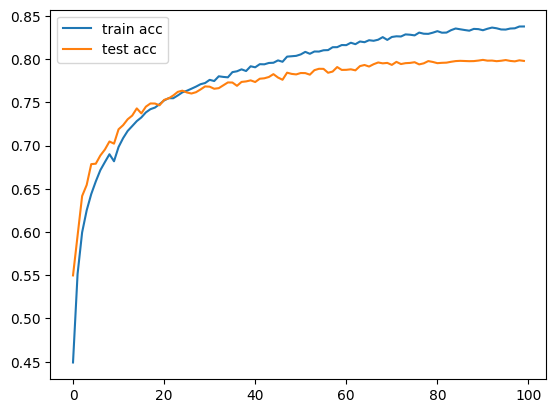

In [24]:
plt.plot(train_accs_w8, label="train acc")
plt.plot(test_accs_w8, label="test acc")
plt.legend()

In [25]:
model_w8_no_kd, best_file_w8_no_kd, train_losses_w8_no_kd, test_losses_w8_no_kd, train_accs_w8_no_kd, test_accs_w8_no_kd = train_loop_full(teacher, epochs=100, 
                                                                                                                                           batch_size=128, lr=1e-3, 
                                                                                                                                           knowledge_distillation=False, 
                                                                                                                                           width=8)

Device: cuda
Parameters: 1,053,442

Epoch   1/100 | train loss 1.527 acc 44.4% | test loss 1.258 acc 54.9% | best 54.9%
Epoch   2/100 | train loss 1.248 acc 55.1% | test loss 1.070 acc 62.4% | best 62.4%
Epoch   3/100 | train loss 1.122 acc 60.0% | test loss 1.034 acc 63.5% | best 63.5%
Epoch   4/100 | train loss 1.055 acc 62.6% | test loss 0.972 acc 66.4% | best 66.4%
Epoch   5/100 | train loss 1.002 acc 64.4% | test loss 0.944 acc 67.0% | best 67.0%
Epoch   6/100 | train loss 0.957 acc 66.1% | test loss 0.902 acc 68.8% | best 68.8%
Epoch   7/100 | train loss 0.931 acc 67.3% | test loss 0.903 acc 69.2% | best 69.2%
Epoch   8/100 | train loss 0.902 acc 68.2% | test loss 0.875 acc 70.2% | best 70.2%
Epoch   9/100 | train loss 0.881 acc 68.9% | test loss 0.881 acc 70.1% | best 70.2%
Epoch  10/100 | train loss 0.855 acc 69.8% | test loss 0.848 acc 71.2% | best 71.2%
Epoch  11/100 | train loss 0.836 acc 70.7% | test loss 0.823 acc 71.8% | best 71.8%
Epoch  12/100 | train loss 0.822 acc 71.

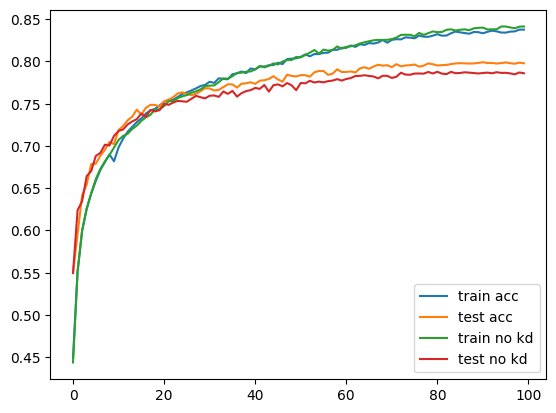

In [26]:
plt.plot(train_accs_w8, label="train acc")
plt.plot(test_accs_w8, label="test acc")
plt.plot(train_accs_w8_no_kd, label="train no kd")
plt.plot(test_accs_w8_no_kd, label="test no kd")
plt.legend()

# Effect of Width

We ran the training for different widths (number of output channels) of the Paulsen network and used Student-Teacher training to boost accuracy.

In [10]:
LR = 1e-3
model_w8, best_file_w8, train_losses_w8, test_losses_w8, train_accs_w8, test_accs_w8 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=True, width=8)
model_w16, best_file_w16, train_losses_w16, test_losses_w16, train_accs_w16, test_accs_w16 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=True, width=16)
model_w32, best_file_w32, train_losses_w32, test_losses_w32, train_accs_w32, test_accs_w32 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=True, width=32)
model_w64, best_file_w64, train_losses_w64, test_losses_w64, train_accs_w64, test_accs_w64 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=True, width=64)

Device: cuda
Parameters: 1,053,442

Epoch   1/100 | train loss 1.509 acc 44.9% | test loss 1.282 acc 54.2% | best 54.2%
Epoch   2/100 | train loss 1.249 acc 55.1% | test loss 1.098 acc 61.8% | best 61.8%
Epoch   3/100 | train loss 1.136 acc 59.5% | test loss 1.022 acc 64.3% | best 64.3%
Epoch   4/100 | train loss 1.064 acc 62.4% | test loss 0.959 acc 66.6% | best 66.6%
Epoch   5/100 | train loss 1.007 acc 64.3% | test loss 0.927 acc 67.5% | best 67.5%
Epoch   6/100 | train loss 0.960 acc 66.1% | test loss 0.901 acc 68.9% | best 68.9%
Epoch   7/100 | train loss 0.925 acc 67.3% | test loss 0.878 acc 70.0% | best 70.0%
Epoch   8/100 | train loss 0.889 acc 68.7% | test loss 0.853 acc 70.5% | best 70.5%
Epoch   9/100 | train loss 0.870 acc 69.4% | test loss 0.853 acc 70.6% | best 70.6%
Epoch  10/100 | train loss 1.908 acc 69.1% | test loss 0.982 acc 71.2% | best 71.2%
Epoch  11/100 | train loss 1.812 acc 70.5% | test loss 0.941 acc 71.9% | best 71.9%
Epoch  12/100 | train loss 1.736 acc 71.

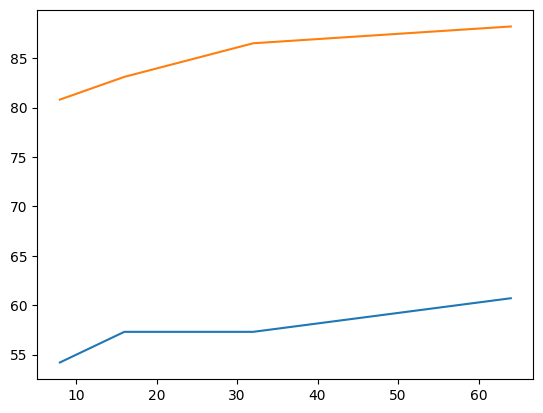

In [11]:
plt.plot([8, 16, 32, 64], [54.2, 57.3, 57.3, 60.7], label="first epoch")
plt.plot([8, 16, 32, 64], [80.8, 83.1, 86.5, 88.2], label="final epoch")

# Fitnet Training

In [ ]:
LR = 1e-3
model_w8, best_file_w8, train_losses_w8, test_losses_w8, train_accs_w8, test_accs_w8 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=False, width=8, fitnet=True, warmup=20)
model_w16, best_file_w16, train_losses_w16, test_losses_w16, train_accs_w16, test_accs_w16 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=False, width=16, fitnet=True, warmup=20)
model_w32, best_file_w32, train_losses_w32, test_losses_w32, train_accs_w32, test_accs_w32 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=False, width=32, fitnet=True, warmup=20)
model_w64, best_file_w64, train_losses_w64, test_losses_w64, train_accs_w64, test_accs_w64 = train_loop_full(teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                                       knowledge_distillation=False, width=64, fitnet=True, warmup=20)

Device: cuda
Parameters: 1,053,442

Epoch   1/100 | train loss 1.148 acc 10.4% | test loss 2.313 acc 10.6% | best 10.6%  - (12.425282001495361 sec)
Epoch   2/100 | train loss 0.707 acc 10.0% | test loss 2.313 acc 10.2% | best 10.6%  - (24.849746704101562 sec)
Epoch   3/100 | train loss 0.664 acc 10.0% | test loss 2.312 acc 11.2% | best 11.2%  - (37.38452363014221 sec)
Epoch   4/100 | train loss 0.624 acc 10.0% | test loss 2.315 acc 10.0% | best 11.2%  - (49.85647416114807 sec)
Epoch   5/100 | train loss 0.600 acc 9.5% | test loss 2.316 acc 9.6% | best 11.2%  - (62.312435150146484 sec)
Epoch   6/100 | train loss 0.589 acc 9.9% | test loss 2.317 acc 9.4% | best 11.2%  - (74.75031542778015 sec)


In [ ]:
plt.plot(train_accs_w8, label="train w8")
plt.plot(train_accs_w16, label="train w16")
plt.plot(train_accs_w32, label="train w32")
plt.plot(train_accs_w64, label="train w64")
plt.plot(test_accs_w8, label="test w8")
plt.plot(test_accs_w16, label="test w16")
plt.plot(test_accs_w32, label="test w32")
plt.plot(test_accs_w64, label="test w64")
plt.legend()
plt.title("FitNet Training")
plt.show()

# Ultra-Tiny

In [16]:
model = make_cnn_tiny(3, 32, width=16, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model, best_file, train_losses, test_losses, train_accs, test_accs = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=True, width=8)

Device: cuda
Parameters: 288,778

Epoch   1/100 | train loss 1.545 acc 43.4% | test loss 1.270 acc 53.7% | best 53.7%  - (11.171473979949951 sec)
Epoch   2/100 | train loss 1.268 acc 54.0% | test loss 1.127 acc 59.2% | best 59.2%  - (21.744667530059814 sec)
Epoch   3/100 | train loss 1.145 acc 59.0% | test loss 1.059 acc 62.4% | best 62.4%  - (32.19665884971619 sec)
Epoch   4/100 | train loss 1.052 acc 62.3% | test loss 0.968 acc 65.6% | best 65.6%  - (42.69248580932617 sec)
Epoch   5/100 | train loss 0.993 acc 64.8% | test loss 0.954 acc 66.3% | best 66.3%  - (53.42339038848877 sec)
Epoch   6/100 | train loss 0.937 acc 66.9% | test loss 0.884 acc 69.6% | best 69.6%  - (63.869266986846924 sec)
Epoch   7/100 | train loss 0.896 acc 68.2% | test loss 0.837 acc 71.2% | best 71.2%  - (74.3472740650177 sec)
Epoch   8/100 | train loss 0.863 acc 69.4% | test loss 0.835 acc 71.0% | best 71.2%  - (84.91165804862976 sec)
Epoch   9/100 | train loss 0.833 acc 70.5% | test loss 0.812 acc 71.4% | bes

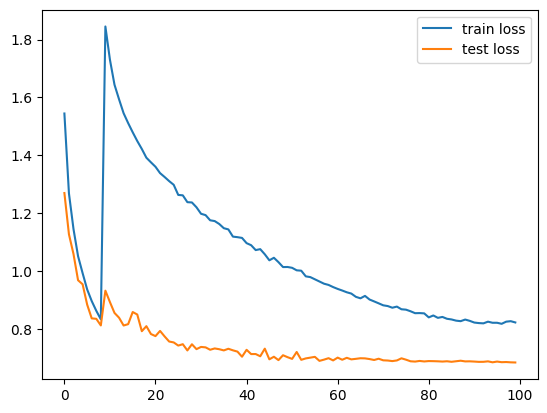

In [20]:
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.legend()
plt.show()

In [21]:
model = make_cnn_tiny(3, 32, width=16, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model, best_file_auto, train_losses_auto, test_losses_auto, train_accs_auto, test_accs_auto = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=True, width=8, auto_augment=True)

Device: cuda
Parameters: 288,778

Epoch   1/100 | train loss 1.658 acc 39.9% | test loss 1.213 acc 55.7% | best 55.7%  - (17.47876238822937 sec)
Epoch   2/100 | train loss 1.339 acc 52.2% | test loss 1.054 acc 62.3% | best 62.3%  - (34.85738563537598 sec)
Epoch   3/100 | train loss 1.191 acc 57.8% | test loss 0.974 acc 65.4% | best 65.4%  - (52.408018827438354 sec)
Epoch   4/100 | train loss 1.076 acc 61.9% | test loss 0.949 acc 66.9% | best 66.9%  - (69.68985390663147 sec)
Epoch   5/100 | train loss 0.996 acc 64.9% | test loss 0.910 acc 68.6% | best 68.6%  - (87.16084551811218 sec)
Epoch   6/100 | train loss 0.937 acc 67.0% | test loss 0.877 acc 69.4% | best 69.4%  - (104.51030659675598 sec)
Epoch   7/100 | train loss 0.877 acc 69.6% | test loss 0.891 acc 69.3% | best 69.4%  - (122.07899069786072 sec)
Epoch   8/100 | train loss 0.832 acc 71.1% | test loss 0.876 acc 70.2% | best 70.2%  - (139.40230870246887 sec)
Epoch   9/100 | train loss 0.783 acc 72.9% | test loss 0.866 acc 71.3% | b

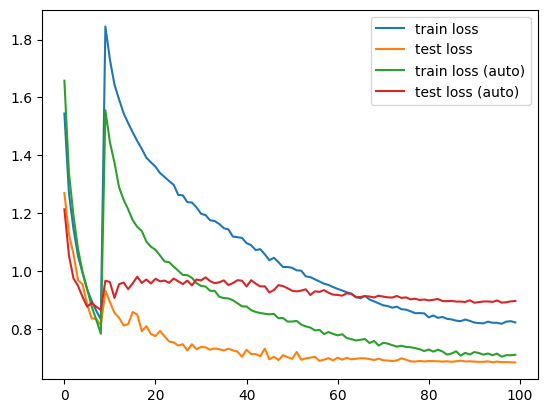

In [22]:
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.plot(train_losses_auto, label="train loss (auto)")
plt.plot(test_losses_auto, label="test loss (auto)")
plt.legend()
plt.show()

In [23]:
model = make_cnn_tiny(3, 32, width=32, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model, best_file_w32, train_losses_w32, test_losses_w32, train_accs_w32, test_accs_w32 = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=True, width=32)

Device: cuda
Parameters: 620,810

Epoch   1/100 | train loss 1.496 acc 45.7% | test loss 1.304 acc 54.2% | best 54.2%  - (10.65848684310913 sec)
Epoch   2/100 | train loss 1.200 acc 56.9% | test loss 1.037 acc 64.0% | best 64.0%  - (21.26509666442871 sec)
Epoch   3/100 | train loss 1.022 acc 63.5% | test loss 0.919 acc 68.0% | best 68.0%  - (31.79971694946289 sec)
Epoch   4/100 | train loss 0.918 acc 67.4% | test loss 0.836 acc 70.4% | best 70.4%  - (42.356204986572266 sec)
Epoch   5/100 | train loss 0.843 acc 70.0% | test loss 0.815 acc 71.5% | best 71.5%  - (52.923752546310425 sec)
Epoch   6/100 | train loss 0.796 acc 71.7% | test loss 0.768 acc 73.5% | best 73.5%  - (63.49854254722595 sec)
Epoch   7/100 | train loss 0.753 acc 73.3% | test loss 0.740 acc 74.4% | best 74.4%  - (74.05055713653564 sec)
Epoch   8/100 | train loss 0.721 acc 74.3% | test loss 0.731 acc 75.0% | best 75.0%  - (84.59778308868408 sec)
Epoch   9/100 | train loss 0.692 acc 75.6% | test loss 0.709 acc 75.8% | bes

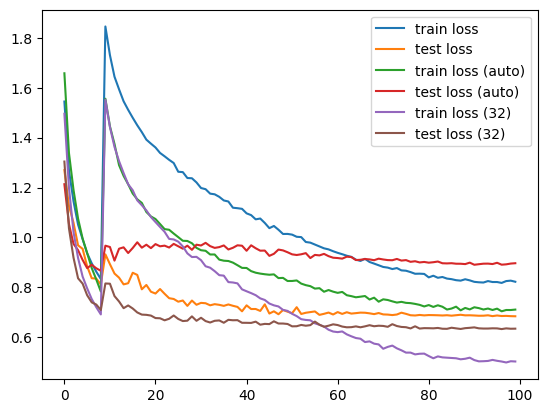

In [24]:
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.plot(train_losses_auto, label="train loss (auto)")
plt.plot(test_losses_auto, label="test loss (auto)")
plt.plot(train_losses_w32, label="train loss (32)")
plt.plot(test_losses_w32, label="test loss (32)")
plt.legend()
plt.show()

## Plain Standard Training

See how well they perform without Student-Teacher training.

In [13]:
model = make_cnn_tiny(3, 32, width=16, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model, best_file, train_losses, test_losses, train_accs, test_accs = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=False, width=8)

model = make_cnn_tiny(3, 32, width=32, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model, best_file_w32, train_losses_w32, test_losses_w32, train_accs_w32, test_accs_w32 = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=False, width=32)

Device: cuda
Parameters: 288,778

Epoch   1/100 | train loss 1.523 acc 44.7% | test loss 1.289 acc 53.3% | best 53.3%  - (11.066818237304688 sec)
Epoch   2/100 | train loss 1.269 acc 54.4% | test loss 1.153 acc 59.0% | best 59.0%  - (21.822248697280884 sec)
Epoch   3/100 | train loss 1.150 acc 58.7% | test loss 1.039 acc 63.2% | best 63.2%  - (32.5960636138916 sec)
Epoch   4/100 | train loss 1.071 acc 61.8% | test loss 1.001 acc 64.6% | best 64.6%  - (43.35738563537598 sec)
Epoch   5/100 | train loss 1.000 acc 64.6% | test loss 0.939 acc 67.0% | best 67.0%  - (54.133949756622314 sec)
Epoch   6/100 | train loss 0.946 acc 66.5% | test loss 0.879 acc 69.4% | best 69.4%  - (64.8770341873169 sec)
Epoch   7/100 | train loss 0.904 acc 68.0% | test loss 0.894 acc 68.6% | best 69.4%  - (75.64766526222229 sec)
Epoch   8/100 | train loss 0.865 acc 69.4% | test loss 0.842 acc 70.0% | best 70.0%  - (86.46644067764282 sec)
Epoch   9/100 | train loss 0.835 acc 70.4% | test loss 0.817 acc 71.7% | best

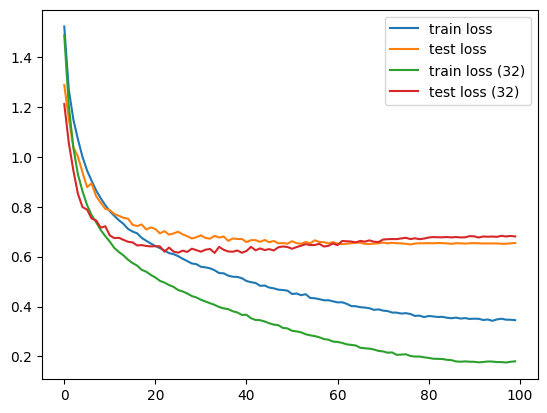

In [14]:
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.plot(train_losses_w32, label="train loss (32)")
plt.plot(test_losses_w32, label="test loss (32)")
plt.legend()
plt.show()

## Different Widths

In [15]:
width = 2
onnx_filename = f"cifar_conv{width}_ultry_tiny.onnx"
model = make_cnn_tiny(3, 32, width=width, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model2, best_file2, train_losses2, test_losses2, train_accs2, test_accs2 = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=True, width=width)
print("best file: ", best_file2)

dummy_input = torch.randn(1, 3, 32, 32)

state_dict = torch.load(best_file2, weights_only=True)
model2.load_state_dict(state_dict)

# 3. Export to ONNX
torch.onnx.export(
    model2,
    dummy_input,
    onnx_filename,
    export_params=True,       # Store the trained parameter weights inside the model file
    opset_version=20,          # The ONNX version to export to
    do_constant_folding=True,  # Whether to execute constant folding for optimization
    input_names=['input'],     # The model's input names
    output_names=['output'],    # The model's output names
    external_data=False
)

print(f"Model successfully exported to {onnx_filename}")

Device: cuda
Parameters: 36,050

Epoch   1/100 | train loss 1.841 acc 33.0% | test loss 1.630 acc 41.1% | best 41.1%  - (10.725991487503052 sec)
Epoch   2/100 | train loss 1.656 acc 39.7% | test loss 1.540 acc 44.4% | best 44.4%  - (21.170191764831543 sec)
Epoch   3/100 | train loss 1.600 acc 42.2% | test loss 1.499 acc 46.2% | best 46.2%  - (31.618988275527954 sec)
Epoch   4/100 | train loss 1.560 acc 44.0% | test loss 1.461 acc 47.7% | best 47.7%  - (42.035903215408325 sec)
Epoch   5/100 | train loss 1.531 acc 44.9% | test loss 1.450 acc 48.3% | best 48.3%  - (52.56534790992737 sec)
Epoch   6/100 | train loss 1.511 acc 45.8% | test loss 1.433 acc 49.2% | best 49.2%  - (62.98803639411926 sec)
Epoch   7/100 | train loss 1.494 acc 46.6% | test loss 1.413 acc 49.7% | best 49.7%  - (73.42619705200195 sec)
Epoch   8/100 | train loss 1.477 acc 46.9% | test loss 1.394 acc 50.2% | best 50.2%  - (83.85688042640686 sec)
Epoch   9/100 | train loss 1.462 acc 47.3% | test loss 1.374 acc 50.9% | be

NameError: name 'dummy_input' is not defined

In [15]:
width = 2
onnx_filename = f"cifar_conv{width}_ultry_tiny.onnx"
model2 = make_cnn_tiny(3, 32, width=width, linear_size=256, act_fun=nn.GELU, act_kwargs={})
dummy_input = torch.randn(1, 3, 32, 32)

state_dict = torch.load('best_model_2026-03-23_09-58-23.pth', weights_only=True)
model2.load_state_dict(state_dict)

# 3. Export to ONNX
torch.onnx.export(
    model2.to('cpu'),
    dummy_input,
    onnx_filename,
    export_params=True,       # Store the trained parameter weights inside the model file
    opset_version=20,          # The ONNX version to export to
    do_constant_folding=True,  # Whether to execute constant folding for optimization
    input_names=['input'],     # The model's input names
    output_names=['output'],    # The model's output names
    external_data=False
)

print(f"Model successfully exported to {onnx_filename}")

Model successfully exported to cifar_conv2_ultry_tiny.onnx


In [16]:
width = 4
onnx_filename = f"cifar_conv{width}_ultry_tiny.onnx"
model = make_cnn_tiny(3, 32, width=width, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model4, best_file4, train_losses4, test_losses4, train_accs4, test_accs4 = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=True, width=width)
print("best file: ", best_file4)

dummy_input = torch.randn(1, 3, 32, 32)

state_dict = torch.load(best_file4, weights_only=True)
model4.load_state_dict(state_dict)

# 3. Export to ONNX
torch.onnx.export(
    model4.to('cpu'),
    dummy_input,
    onnx_filename,
    export_params=True,       # Store the trained parameter weights inside the model file
    opset_version=20,          # The ONNX version to export to
    do_constant_folding=True,  # Whether to execute constant folding for optimization
    input_names=['input'],     # The model's input names
    output_names=['output'],    # The model's output names
    external_data=False
)

print(f"Model successfully exported to {onnx_filename}")

Device: cuda
Parameters: 69,994

Epoch   1/100 | train loss 1.716 acc 37.6% | test loss 1.479 acc 46.4% | best 46.4%  - (10.965781688690186 sec)
Epoch   2/100 | train loss 1.498 acc 45.6% | test loss 1.376 acc 50.6% | best 50.6%  - (21.74018692970276 sec)
Epoch   3/100 | train loss 1.420 acc 48.5% | test loss 1.321 acc 52.1% | best 52.1%  - (32.51201558113098 sec)
Epoch   4/100 | train loss 1.373 acc 50.4% | test loss 1.305 acc 52.9% | best 52.9%  - (43.25113368034363 sec)
Epoch   5/100 | train loss 1.332 acc 52.3% | test loss 1.259 acc 54.9% | best 54.9%  - (53.99900007247925 sec)
Epoch   6/100 | train loss 1.305 acc 53.1% | test loss 1.225 acc 56.3% | best 56.3%  - (64.8366813659668 sec)
Epoch   7/100 | train loss 1.280 acc 54.0% | test loss 1.208 acc 56.6% | best 56.6%  - (75.63626790046692 sec)
Epoch   8/100 | train loss 1.259 acc 54.7% | test loss 1.194 acc 57.3% | best 57.3%  - (86.39894580841064 sec)
Epoch   9/100 | train loss 1.240 acc 55.6% | test loss 1.182 acc 57.9% | best 5

In [14]:
width = 8
onnx_filename = f"cifar_conv{width}_ultry_tiny.onnx"
model = make_cnn_tiny(3, 32, width=width, linear_size=256, act_fun=nn.GELU, act_kwargs={})
model2, best_file2, train_losses2, test_losses2, train_accs2, test_accs2 = train_loop_var_model_full(model, teacher, epochs=100, batch_size=128, lr=1e-3, 
                                                                                               knowledge_distillation=True, width=width)
print("best file: ", best_file2)

# 3. Export to ONNX
torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    export_params=True,       # Store the trained parameter weights inside the model file
    opset_version=20,          # The ONNX version to export to
    do_constant_folding=True,  # Whether to execute constant folding for optimization
    input_names=['input'],     # The model's input names
    output_names=['output'],    # The model's output names
    external_data=False
)

print(f"Model successfully exported to {onnx_filename}")

Device: cuda
Parameters: 140,042

Epoch   1/100 | train loss 1.616 acc 41.1% | test loss 1.359 acc 50.4% | best 50.4%  - (10.998918294906616 sec)
Epoch   2/100 | train loss 1.398 acc 49.2% | test loss 1.278 acc 54.0% | best 54.0%  - (21.54775381088257 sec)
Epoch   3/100 | train loss 1.308 acc 52.7% | test loss 1.219 acc 56.0% | best 56.0%  - (32.0805766582489 sec)
Epoch   4/100 | train loss 1.245 acc 55.0% | test loss 1.172 acc 57.8% | best 57.8%  - (42.610411405563354 sec)
Epoch   5/100 | train loss 1.197 acc 57.2% | test loss 1.132 acc 59.8% | best 59.8%  - (53.24880242347717 sec)
Epoch   6/100 | train loss 1.156 acc 58.5% | test loss 1.104 acc 60.6% | best 60.6%  - (63.79013919830322 sec)
Epoch   7/100 | train loss 1.120 acc 60.0% | test loss 1.083 acc 61.3% | best 61.3%  - (74.32395815849304 sec)
Epoch   8/100 | train loss 1.087 acc 61.3% | test loss 1.046 acc 62.9% | best 62.9%  - (85.40059733390808 sec)
Epoch   9/100 | train loss 1.061 acc 62.2% | test loss 1.036 acc 63.5% | best

NameError: name 'dummy_input' is not defined

In [15]:
width = 8
onnx_filename = f"cifar_conv{width}_ultra_tiny.onnx"
model2 = make_cnn_tiny(3, 32, width=width, linear_size=256, act_fun=nn.GELU, act_kwargs={})
dummy_input = torch.randn(1, 3, 32, 32)

state_dict = torch.load('best_model_2026-03-30_10-11-28.pth', weights_only=True)
model2.load_state_dict(state_dict)

# 3. Export to ONNX
torch.onnx.export(
    model2.to('cpu'),
    dummy_input,
    onnx_filename,
    export_params=True,       # Store the trained parameter weights inside the model file
    opset_version=20,          # The ONNX version to export to
    do_constant_folding=True,  # Whether to execute constant folding for optimization
    input_names=['input'],     # The model's input names
    output_names=['output'],    # The model's output names
    external_data=False
)

print(f"Model successfully exported to {onnx_filename}")

Model successfully exported to cifar_conv8_ultra_tiny.onnx
